In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle, SpectrumFitRow
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit
import os
import itertools
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
import logging
from matplotlib.patches import Rectangle
from astroscrappy import detect_cosmics
from sospice import spice_error

from copy import deepcopy
from glob import glob

In [3]:
spice_raster = read_spice_l2_fits("../src/solo_L2_spice-n-ras_20221024T231535_V22_150995398-000.fits")

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-05 16:48:18 - astropy - WARNING: FITSFixedWarning: CROTA = 4.69616384906 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.969164 from DATE-OBS.
Set MJD-BEG to 59876.969164 from DATE-BEG.
Set MJD-AVG to 59877.036108 from DATE-AVG.
Set MJD-END to 59877.103050 from DATE-END'. [astropy.wcs.wcs]
2025-03-05 16:48:18 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.969164 from DATEREF.
Set MJD-OBS to 59876.969164 from DATE-OBS.
Set MJD-BEG to 59876.969164 from DATE-BEG.
Set MJD-AVG to 59877.036108 from DATE-AVG.
Set MJD-END to 59877.103050 from DATE-END'.


In [4]:
spice_NeVIII_770_window = spice_raster["Ne VIII 770 - Peak"]

In [6]:
spice_NeVIII_dark_noise, spice_NeVIII_sigma = spice_error(data=spice_NeVIII_770_window.data, header=spice_NeVIII_770_window.meta.original_header)

Getting observation parameters from Ne VIII 770 - Peak

Slit: 4.0 arcsec
Bin: (1, 1)
Exposure time: 60.0 s
Window width: 50.0 pix
Average wavelength: 77.04555580990001 nm
RADCAL: 241.233601943 m2 ct nm sr / W
            


In [9]:
spice_NeVIII_sigma['Read'].to_value()

0.04045072287516582

In [22]:
data_cleaned = np.zeros_like(spice_NeVIII_770_window.data[0])

for ii in range(data_cleaned.shape[0]):
    test_mask, test_img_cleaned = detect_cosmics(spice_NeVIII_770_window.data[0, 24,:,:],)
    data_cleaned[ii,:,:] = test_img_cleaned

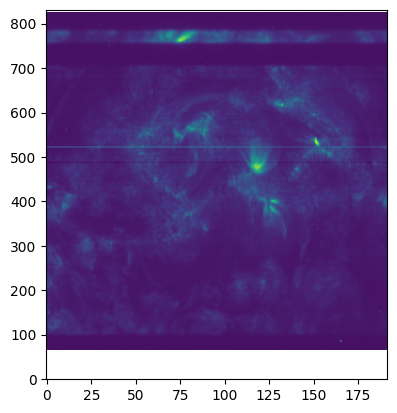

In [26]:
plt.imshow(data_cleaned[23,:,:], origin="lower", aspect=1/4)

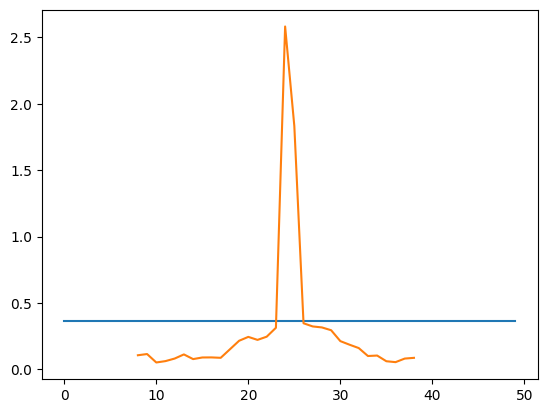

In [23]:
plt.plot(data_cleaned[:,120+200*2,20])
plt.plot(spice_NeVIII_770_window.data[0, :,120+201*2,20])